# EDA: Telco Customer Churn

**Цель:** понять структуру данных, найти закономерности, связанные с оттоком,
и сформулировать гипотезы для feature engineering.

**Датасет:** [Telco Customer Churn (Kaggle)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)
— 7043 строки, 21 признак.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
RAW_PATH = Path('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [23]:
df = pd.read_csv(RAW_PATH)
print(f"Shape: {df.shape}")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [26]:
df.isna().sum().sort_values(ascending=False)

#(df == ' ').sum().sort_values(ascending=False)

TotalCharges        11
customerID           0
DeviceProtection     0
MonthlyCharges       0
PaymentMethod        0
PaperlessBilling     0
Contract             0
StreamingMovies      0
StreamingTV          0
TechSupport          0
OnlineBackup         0
gender               0
OnlineSecurity       0
InternetService      0
MultipleLines        0
PhoneService         0
tenure               0
Dependents           0
Partner              0
SeniorCitizen        0
Churn                0
dtype: int64

In [27]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Churn
No     5174
Yes    1869
Name: count, dtype: int64

Дисбаланс: 26.54% churn


C:\Users\Никита\AppData\Local\Temp\ipykernel_25748\3938732780.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', ax=ax[0], palette='Set2')
C:\Users\Никита\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Никита\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a fu

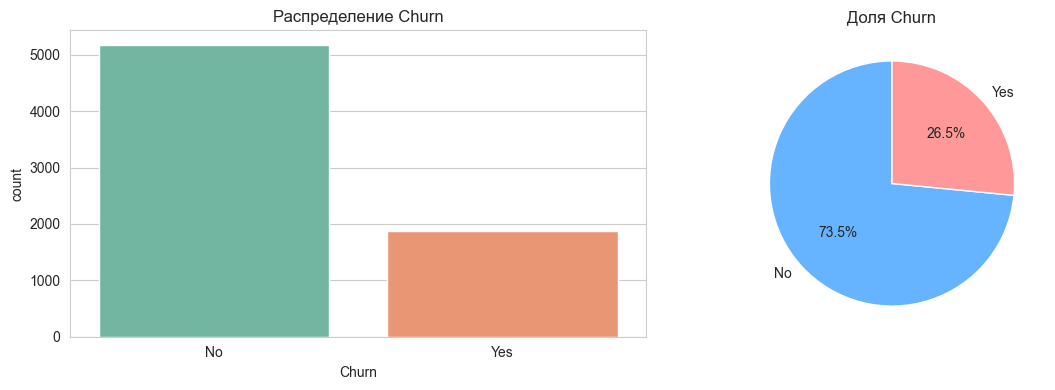

In [28]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print(churn_counts)
print(f"\nДисбаланс: {churn_pct['Yes']:.2f}% churn")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x='Churn', ax=ax[0], palette='Set2')
ax[0].set_title('Распределение Churn')

ax[1].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
          colors=['#66b3ff', '#ff9999'], startangle=90)
ax[1].set_title('Доля Churn')
plt.tight_layout()
plt.savefig('../reports/figures/churn_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

C:\Users\Никита\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Никита\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Никита\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_base.py:948: FutureWarning: When groupi

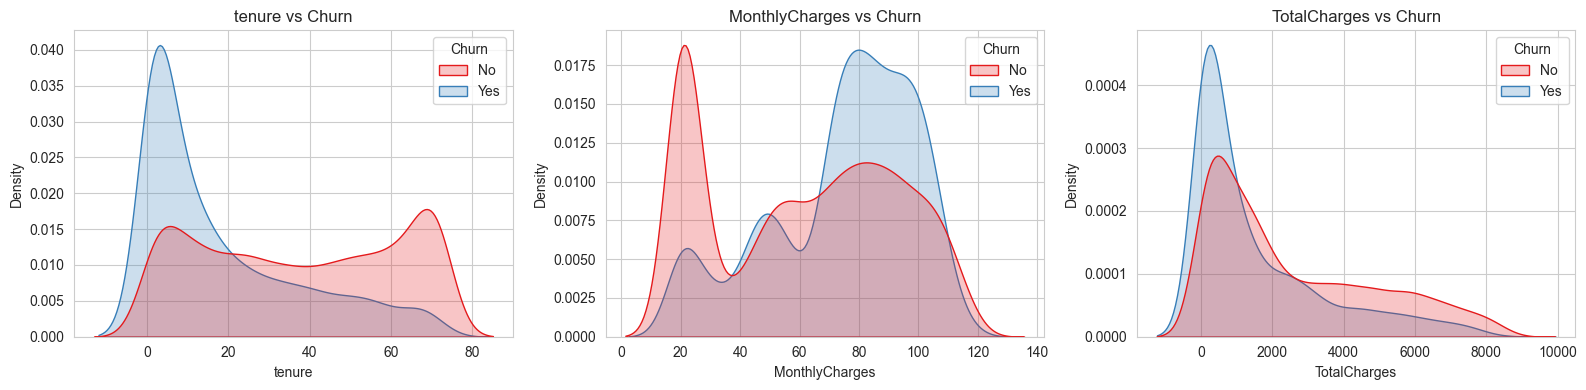

In [29]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, col in enumerate(num_cols):
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True,
                ax=axes[i], palette='Set1', common_norm=False)
    axes[i].set_title(f'{col} vs Churn')
plt.tight_layout()
plt.savefig('../reports/figures/numeric_vs_churn.png', dpi=100, bbox_inches='tight')
plt.show()

C:\Users\Никита\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Никита\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
C:\Users\Никита\AppData\Local\Packages\PythonSoftwareFoundati

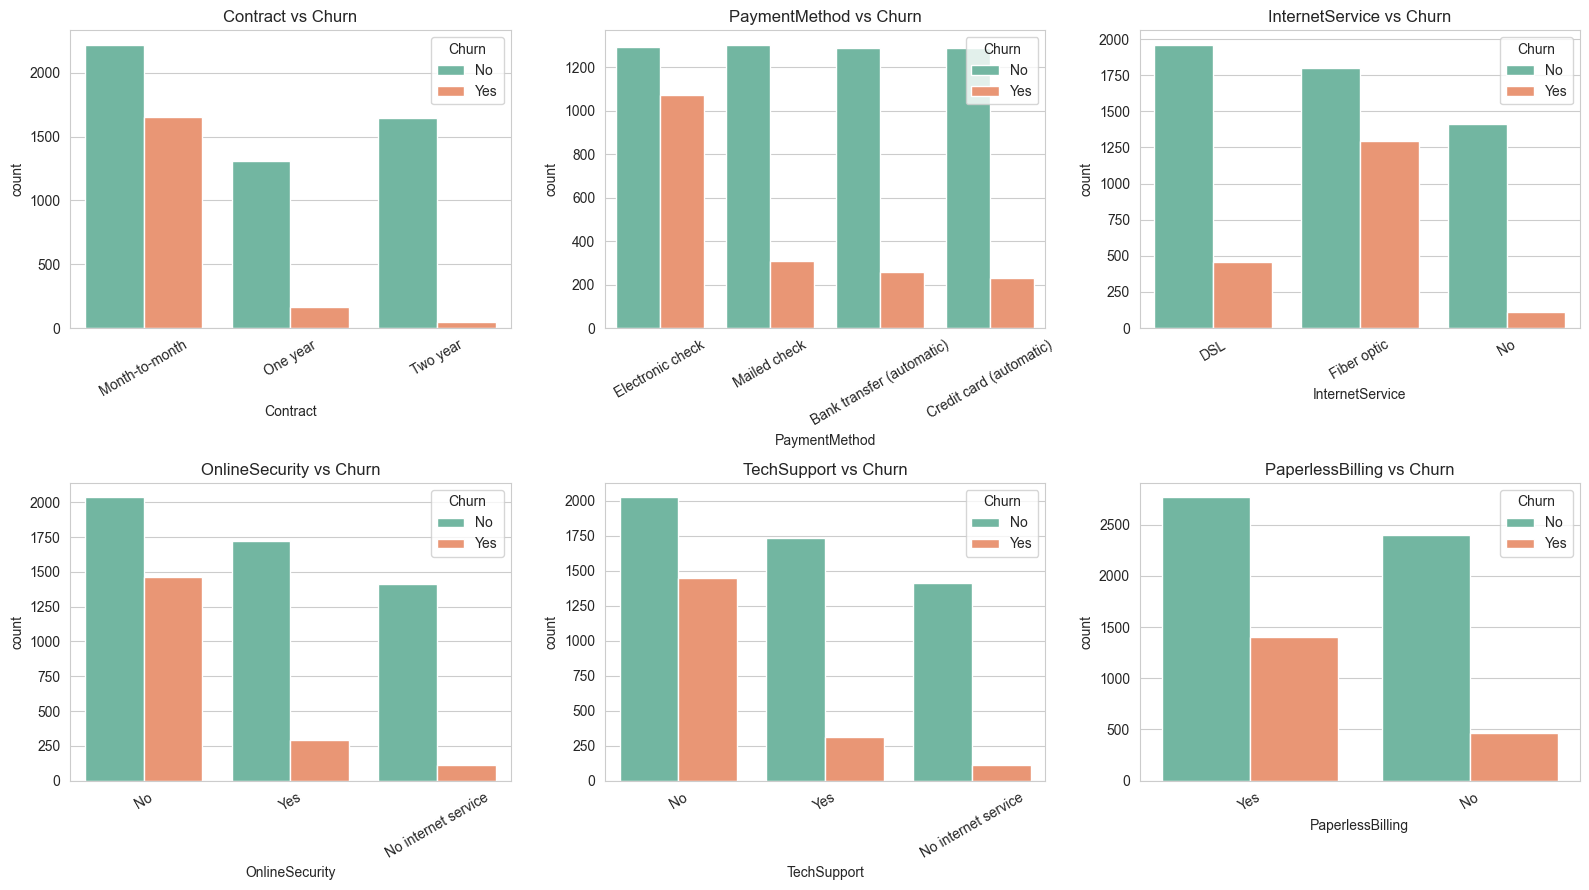

In [30]:
cat_cols = ['Contract', 'PaymentMethod', 'InternetService',
            'OnlineSecurity', 'TechSupport', 'PaperlessBilling']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for i, col in enumerate(cat_cols):
    ax = axes[i // 3, i % 3]
    sns.countplot(data=df, x=col, hue='Churn', ax=ax, palette='Set2')
    ax.set_title(f'{col} vs Churn')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('../reports/figures/categorical_vs_churn.png', dpi=100, bbox_inches='tight')
plt.show()

In [31]:
churn_by_contract = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(2).sort_values(ascending=False)

print("Churn rate по типу контракта (%):")
print(churn_by_contract)

Churn rate по типу контракта (%):
Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64


Churn rate по стажу (%):
tenure_group
0-1y    47.44
1-2y    28.71
2-4y    20.39
4-6y     9.51
Name: Churn, dtype: float64


C:\Users\Никита\AppData\Local\Temp\ipykernel_25748\865065931.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_by_tenure.index, y=churn_by_tenure.values, palette='Reds_r')
C:\Users\Никита\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Никита\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is de

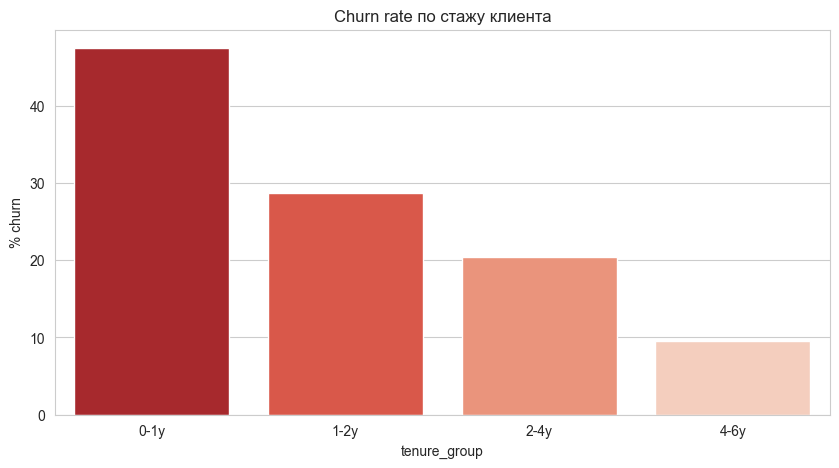

In [32]:
df['tenure_group'] = pd.cut(df['tenure'],
                            bins=[-1, 12, 24, 48, 72],
                            labels=['0-1y', '1-2y', '2-4y', '4-6y'])

churn_by_tenure = df.groupby('tenure_group', observed=True)['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(2)

print("Churn rate по стажу (%):")
print(churn_by_tenure)

sns.barplot(x=churn_by_tenure.index, y=churn_by_tenure.values, palette='Reds_r')
plt.title('Churn rate по стажу клиента')
plt.ylabel('% churn')
plt.savefig('../reports/figures/churn_by_tenure.png', dpi=100, bbox_inches='tight')
plt.show()

In [46]:
risky = df[
    (df['Contract'] == 'Month-to-month') &
    (df['InternetService'] == 'Fiber optic') &
    (df['TechSupport'] == 'No')
]

print(f"Размер рисковой группы: {len(risky)} ({len(risky)/len(df)*100:.1f}%)")
print(f"Churn rate в ней: {(risky['Churn'] == 'Yes').mean()*100:.2f}%")

Размер рисковой группы: 1796 (25.5%)
Churn rate в ней: 57.52%


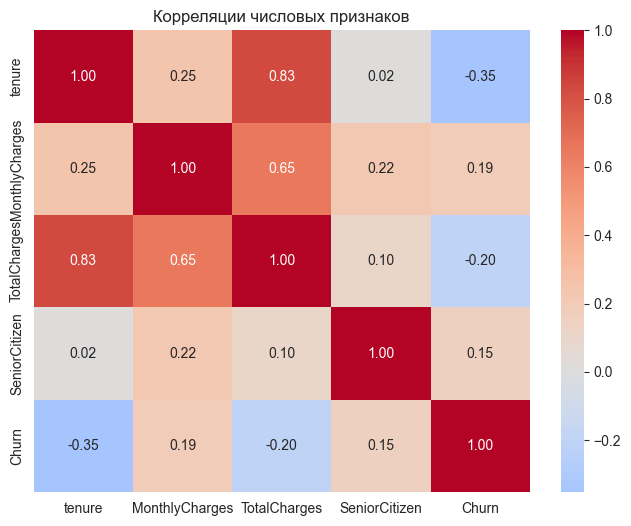

In [35]:
df_corr = df.copy()
df_corr['Churn'] = (df_corr['Churn'] == 'Yes').astype(int)
df_corr['TotalCharges'] = pd.to_numeric(df_corr['TotalCharges'], errors='coerce')

num_df = df_corr[['tenure', 'MonthlyCharges', 'TotalCharges',
                  'SeniorCitizen', 'Churn']]

plt.figure(figsize=(8, 6))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Корреляции числовых признаков')
plt.savefig('../reports/figures/correlation_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

In [36]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = num_df.drop(columns=['Churn']).dropna()
vif_data = pd.DataFrame({
    'feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
print(vif_data.sort_values('VIF', ascending=False))

          feature       VIF
2    TotalCharges  8.085198
0          tenure  6.332737
1  MonthlyCharges  3.701617
3   SeniorCitizen  1.257569


In [44]:
df['expected_charges'] = df['tenure'] * df['MonthlyCharges']

df['charge_diff_pct'] = (
    (df['TotalCharges'] - df['expected_charges']).abs()
    / df['expected_charges'].replace(0, np.nan)
    * 100
)

anomalies = df[df['charge_diff_pct'] > 10]
print(f"Аномалий по расхождению charges: {len(anomalies)}")
anomalies[['customerID', 'tenure', 'MonthlyCharges',
           'TotalCharges', 'expected_charges', 'charge_diff_pct']].head(10)

Аномалий по расхождению charges: 381


,customerID,tenure,MonthlyCharges,TotalCharges,expected_charges,charge_diff_pct
21,1680-VDCWW,12,19.80,202.25,237.60,14.877946
42,9867-JCZSP,17,20.75,418.25,352.75,18.568391
47,7760-OYPDY,2,80.65,144.15,161.30,10.632362
69,7410-OIEDU,10,79.85,887.35,798.50,11.127113
77,5590-ZSKRV,8,54.65,482.25,437.20,10.304209
105,6180-YBIQI,5,24.30,100.20,121.50,17.530864
124,7219-TLZHO,4,20.85,62.90,83.40,24.580336
171,1875-QIVME,2,104.40,242.80,208.80,16.283525
223,0742-MOABM,4,50.05,179.35,200.20,10.414585
239,9227-UAQFT,16,19.75,284.35,316.00,10.015823


In [45]:
df['is_charge_anomaly'] = (df['charge_diff_pct'] > 50).astype(int)
df = df.drop(columns=['expected_charges', 'charge_diff_pct'], errors='ignore')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,is_charge_anomaly
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-1y,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,2-4y,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-1y,0
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,2-4y,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-1y,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,1-2y,0
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,4-6y,0
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,0-1y,0
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,0-1y,0


## 📌 Выводы EDA

**Данные:** 7043 строки, 26.5% churn (умеренный дисбаланс).
`TotalCharges` — число с 11 NaN

**Топ-факторы churn:**
- `Contract = Month-to-month` → 42.7%
- `tenure < 12 мес` → ~48%
- `Fiber optic` без `TechSupport` → 78%
- `Electronic check` → 45%

**Ключевой инсайт:** 25.5% клиентов (month-to-month + fiber + no support)
дают 57.52% всех уходов.

**Аномалии:** 5.4% записей с расхождением `TotalCharges` vs `tenure × MonthlyCharges`.
Не ошибки — смена тарифа/скидки. Не удаляем, добавим флаг `is_charge_anomaly`.

**Мультиколлинеарность:** `tenure` ↔ `TotalCharges` (VIF > 5) → заменим на `avg_charges`.

**Гипотезы для features:**
- `avg_charges = TotalCharges / (tenure + 1)`
- `num_services` — количество подключённых услуг
- `is_new_client` — tenure < 6
- `tenure_group` — бины [0, 12, 24, 48, 72]
- `is_charge_anomaly` — флаг расхождения > 50%
- `has_support` — есть ли tech support / online security

**Бизнес-рекомендация:** таргетировать month-to-month клиентов
со стажем < 12 мес, предлагать годовую подписку + tech support.